In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

# Step 1: Read the Data

In [4]:
%time df = pd.read_csv('Current_Employee_Names,_Salaries,_and_Position_Titles.csv')

CPU times: user 80.8 ms, sys: 21.2 ms, total: 102 ms
Wall time: 132 ms


# Step 2a: Overview of the data

In [3]:
type(df)

pandas.core.frame.DataFrame

In [4]:
# Q: How many rows and columns are in the data?
df.shape

(32278, 8)

In [5]:
df.size # (number of rows) x (number of columns)

258224

In [6]:
df

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
0,"AARON, JEFFERY M",LIEUTENANT,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$160,800.00",NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$136,362.00",NaN
2,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,DEPARTMENT OF WATER MANAGEMENT,F,SALARY,NaN,"$137,436.00",NaN
3,"ABARCA-COMPTON, RUTH A",ATTORNEY - EXCLUDED,CHICAGO DEPARTMENT OF PUBLIC HEALTH,F,SALARY,NaN,"$131,124.00",NaN
4,"ABARCA, EMMANUEL",CONCRETE LABORER,CHICAGO DEPARTMENT OF TRANSPORTATION,F,HOURLY,40.0,NaN,$51.40
...,...,...,...,...,...,...,...,...
32273,"ZYLINSKA JEDD, KLAUDIA",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$108,012.00",NaN
32274,"ZYMANTAS, LAURA C",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$108,012.00",NaN
32275,"ZYMANTAS, MARK E",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$119,976.00",NaN
32276,"ZYRKOWSKI, CARLO E",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$123,444.00",NaN


In [7]:
df.head()

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
0,"AARON, JEFFERY M",LIEUTENANT,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$160,800.00",NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,"$136,362.00",NaN
2,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,DEPARTMENT OF WATER MANAGEMENT,F,SALARY,NaN,"$137,436.00",NaN
3,"ABARCA-COMPTON, RUTH A",ATTORNEY - EXCLUDED,CHICAGO DEPARTMENT OF PUBLIC HEALTH,F,SALARY,NaN,"$131,124.00",NaN
4,"ABARCA, EMMANUEL",CONCRETE LABORER,CHICAGO DEPARTMENT OF TRANSPORTATION,F,HOURLY,40.0,NaN,$51.40


In [8]:
# Q: What are the row indices?
df.index

RangeIndex(start=0, stop=32278, step=1)

In [9]:
# Q: What are the column names?
df.columns

Index(['Name', 'Job Titles', 'Department', 'Full or Part-Time',
       'Salary or Hourly', 'Typical Hours', 'Annual Salary', 'Hourly Rate'],
      dtype='object')

In [10]:
# Q: What does a row of raw data look like?
df.iloc[2]

Name                             ABAD JR, VICENTE M
Job Titles                        CIVIL ENGINEER IV
Department           DEPARTMENT OF WATER MANAGEMENT
Full or Part-Time                                 F
Salary or Hourly                             SALARY
Typical Hours                                   NaN
Annual Salary                           $137,436.00
Hourly Rate                                     NaN
Name: 2, dtype: object

In [11]:
# Q: What column data types did Pandas infer?
df.dtypes

Name                  object
Job Titles            object
Department            object
Full or Part-Time     object
Salary or Hourly      object
Typical Hours        float64
Annual Salary         object
Hourly Rate           object
dtype: object

In [12]:
# Q: How much memory is used?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32278 entries, 0 to 32277
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               32278 non-null  object 
 1   Job Titles         32278 non-null  object 
 2   Department         32278 non-null  object 
 3   Full or Part-Time  32275 non-null  object 
 4   Salary or Hourly   32278 non-null  object 
 5   Typical Hours      7258 non-null   float64
 6   Annual Salary      25020 non-null  object 
 7   Hourly Rate        7258 non-null   object 
dtypes: float64(1), object(7)
memory usage: 2.0+ MB


In [20]:
# Change Annual Salary and Hourly Rate to numeric type
for col in ['Annual Salary', 'Hourly Rate']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[\$,]', '', regex=True)  # Remove symbols
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce') 

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32278 entries, 0 to 32277
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               32278 non-null  object 
 1   Job Titles         32278 non-null  object 
 2   Department         32278 non-null  object 
 3   Full or Part-Time  32275 non-null  object 
 4   Salary or Hourly   32278 non-null  object 
 5   Typical Hours      7258 non-null   float64
 6   Annual Salary      25020 non-null  float64
 7   Hourly Rate        7258 non-null   float64
dtypes: float64(3), object(5)
memory usage: 2.0+ MB


In [21]:
df.describe().transpose() # Only numerical columns

,count,mean,std,min,25%,50%,75%,max
Typical Hours,7258.0,37.051529,7.222451,10.0,40.00,40.00,40.0,40.00
Annual Salary,25020.0,109023.199597,26917.793411,34176.0,93252.00,108012.00,123444.0,350000.04
Hourly Rate,7258.0,45.868633,14.564218,4.0,43.01,48.73,54.3,70.87


In [22]:
df.describe(include=object).T # Only non-numerical columns

,count,unique,top,freq
Name,32278,31919,"HERNANDEZ, JUAN C",5
Job Titles,32278,1199,POLICE OFFICER,7944
Department,32278,39,CHICAGO POLICE DEPARTMENT,12234
Full or Part-Time,32275,2,F,31241
Salary or Hourly,32278,2,SALARY,25020


In [23]:
# Q: Number of missing data per column?
len(df) - df.count()

Name                     0
Job Titles               0
Department               0
Full or Part-Time        3
Salary or Hourly         0
Typical Hours        25020
Annual Salary         7258
Hourly Rate          25020
dtype: int64

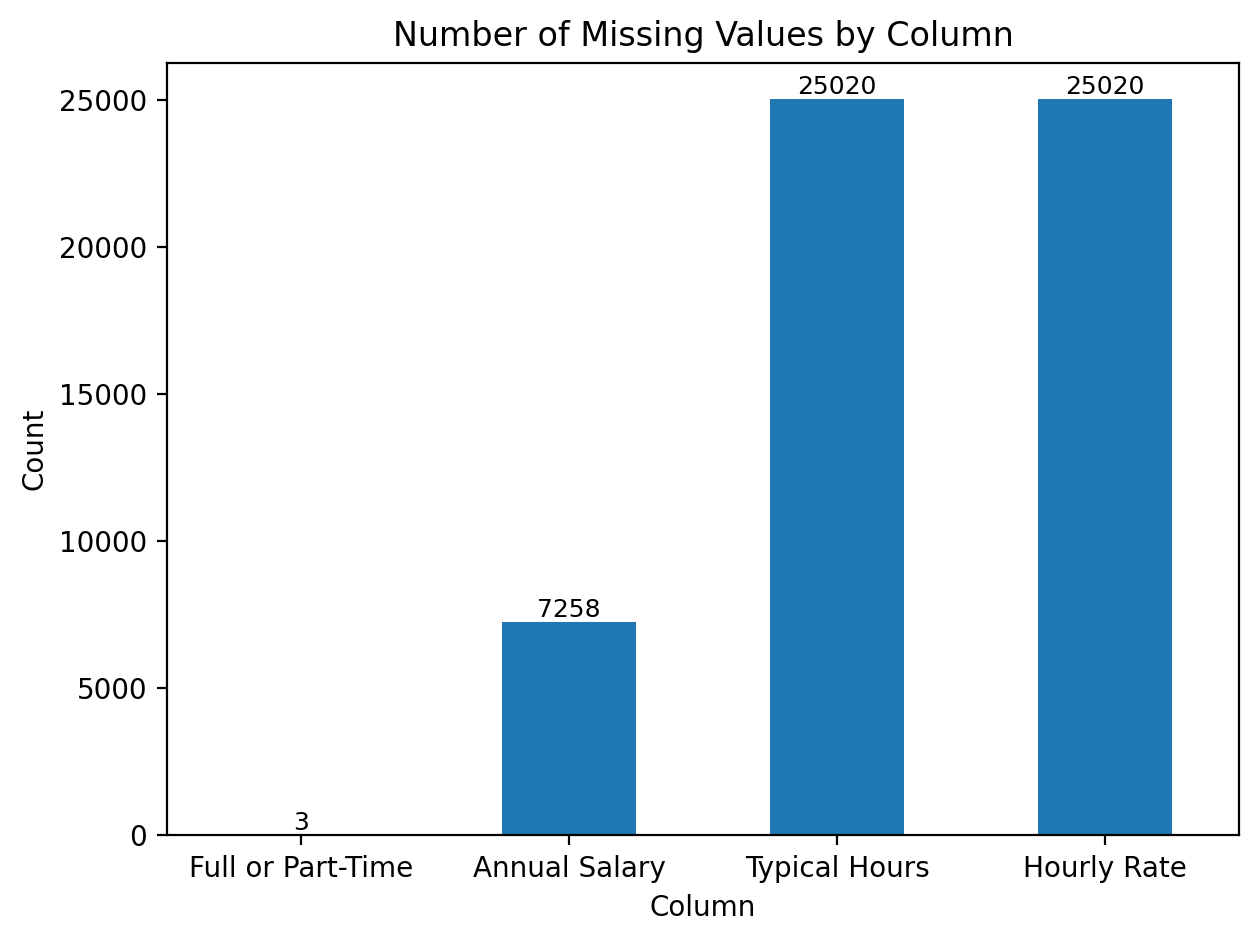

In [45]:
missing_counts = df.isnull().sum().sort_values(ascending=True)
missing_counts = missing_counts[missing_counts > 0]

ax = missing_counts.plot(kind='bar')
plt.title('Number of Missing Values by Column', fontsize=12)
plt.ylabel('Count')
plt.xlabel('Column')
plt.xticks(rotation=0)

bars = ax.patches
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Step 2b: Examine each column of the data for anomaly

## Name

In [27]:
df['Name'].isna().sum()

np.int64(0)

In [28]:
df['Name'].nunique()

31919

In [78]:
df['Name'].duplicated().any() # Has duplicated name

np.True_

In [77]:
df['Name'].duplicated().sum()

np.int64(359)

In [79]:
# Find duplicated names
dup_names = df[df['Name'].duplicated(keep=False)].sort_values('Name')
dup_names.head(10)

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
503,"ALLEN, DAVID",STUDENT INTERN,CHICAGO DEPARTMENT OF AVIATION,P,HOURLY,20.0,NaN,19.00
504,"ALLEN, DAVID",POLICE OFFICER / FLD TRNG OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,129756.0,NaN
683,"ALVAREZ, JUAN",LAMP MAINTENANCE WORKER,CHICAGO DEPARTMENT OF TRANSPORTATION,F,HOURLY,40.0,NaN,35.26
684,"ALVAREZ, JUAN",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,111804.0,NaN
697,"ALVAREZ, MARK A",STAFF ASST TO THE ALDERMAN,CITY COUNCIL,F,SALARY,NaN,51996.0,NaN
698,"ALVAREZ, MARK A",PARAMEDIC,CHICAGO FIRE DEPARTMENT,F,SALARY,NaN,88770.0,NaN
727,"AMADOR, ANGEL",LIBRARY ASSOCIATE,CHICAGO PUBLIC LIBRARY,F,SALARY,NaN,61140.0,NaN
728,"AMADOR, ANGEL",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,123444.0,NaN
871,"ANDERSON, RHONDA M",LIEUTENANT,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,165726.0,NaN
870,"ANDERSON, RHONDA M",SENIOR ADMINISTRATIVE ASSISTANT,DEPARTMENT OF BUSINESS AFFAIRS AND CONSUMER PR...,F,SALARY,NaN,83604.0,NaN


In [152]:
# check how many rows are totaly duplicated for same name, department, job, and salary
duplicates_full = df[df.duplicated(keep=False)]
duplicates_full

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
5280,"COLLINS, BRIAN",SERGEANT,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,134292.0,NaN
5281,"COLLINS, BRIAN",SERGEANT,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,134292.0,NaN
7371,"DOSS, LAUREN A",SENIOR OPERATIONS ANALYST,DEPARTMENT OF WATER MANAGEMENT,F,SALARY,NaN,75384.0,NaN
7372,"DOSS, LAUREN A",SENIOR OPERATIONS ANALYST,DEPARTMENT OF WATER MANAGEMENT,F,SALARY,NaN,75384.0,NaN
9580,"GARCIA, DAVID",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,111804.0,NaN
9581,"GARCIA, DAVID",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,111804.0,NaN
10538,"GONZALEZ, VICTOR H",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,108012.0,NaN
10539,"GONZALEZ, VICTOR H",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,108012.0,NaN
12297,"HERRERA, SERGIO",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,115686.0,NaN
12298,"HERRERA, SERGIO",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,115686.0,NaN


In [153]:
duplicates_full.shape[0]  # delete the duplicated data later

22

## Job Titles

In [25]:
df['Job Titles'].isna().sum()

np.int64(0)

In [33]:
df['Job Titles'].unique()

array(['LIEUTENANT', 'POLICE OFFICER (ASSIGNED AS DETECTIVE)',
       'CIVIL ENGINEER IV', ...,
       'ASST AGING/DISABIL RESOURCE NETWORK MGR',
       'PROGRAMMER-BOARD OF ELECTIONS', 'PRINCIPAL DATA ANALYST'],
      dtype=object)

In [9]:
df['Job Titles'].nunique()

1199

In [134]:
df['Job Titles'].unique()[:20]

array(['LIEUTENANT', 'POLICE OFFICER (ASSIGNED AS DETECTIVE)',
       'CIVIL ENGINEER IV', 'ATTORNEY - EXCLUDED', 'CONCRETE LABORER',
       'SENIOR SECURITY ANALYST', 'ELECTRICAL MECHANIC',
       'FOSTER GRANDPARENT', 'POLICE OFFICER / FLD TRNG OFFICER',
       'PARAMEDIC I/C', 'SERGEANT', 'POLICE OFFICER',
       'LIEUTENANT-PARAMEDIC', 'FIREFIGHTER/PARAMEDIC', 'FIREFIGHTER-EMT',
       'AIRPORT OPERATIONS SUPVSR I', 'POOL MOTOR TRUCK DRIVER',
       'PARKING ENFORCEMENT AIDE', 'AVIATION COMMUNICATIONS OPERATOR',
       'ASST DIR OF INFORMATION SYSTEMS'], dtype=object)

In [34]:
df['Job Titles'].value_counts().head(10)

Job Titles
POLICE OFFICER                            7944
FIREFIGHTER-EMT                           1486
SERGEANT                                  1309
POLICE OFFICER (ASSIGNED AS DETECTIVE)    1133
MOTOR TRUCK DRIVER                         939
POOL MOTOR TRUCK DRIVER                    770
FIREFIGHTER-EMT (RECRUIT)                  662
SANITATION LABORER                         637
LIEUTENANT-EMT                             471
CONSTRUCTION LABORER                       455
Name: count, dtype: int64

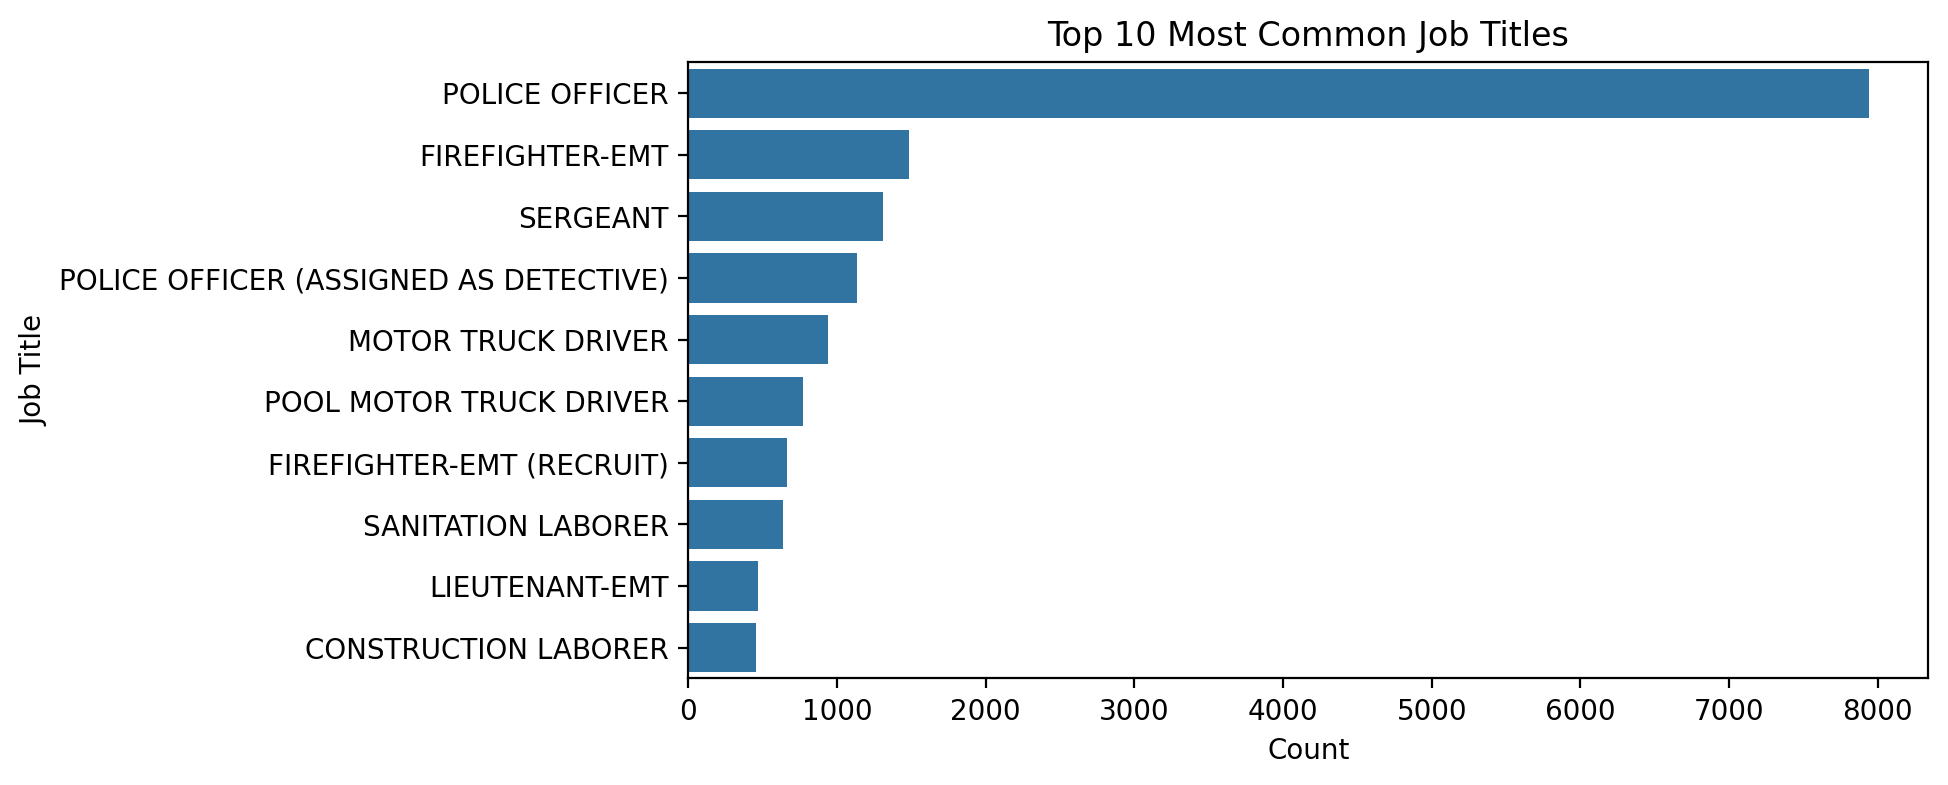

In [10]:
plt.figure(figsize=(8,4))
sns.barplot(x=df['Job Titles'].value_counts().head(10).values,
            y=df['Job Titles'].value_counts().head(10).index)
plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

## Department

In [37]:
df['Department'].isna().sum()

np.int64(0)

In [38]:
df['Department'].unique()

array(['CHICAGO POLICE DEPARTMENT', 'DEPARTMENT OF WATER MANAGEMENT',
       'CHICAGO DEPARTMENT OF PUBLIC HEALTH',
       'CHICAGO DEPARTMENT OF TRANSPORTATION',
       'DEPARTMENT OF TECHNOLOGY AND INNOVATION',
       'CHICAGO DEPARTMENT OF AVIATION',
       'DEPARTMENT OF FAMILY AND SUPPORT SERVICES',
       'CHICAGO FIRE DEPARTMENT', 'DEPARTMENT OF STREETS AND SANITATION',
       'DEPARTMENT OF FINANCE',
       'DEPARTMENT OF FLEET AND FACILITY MANAGEMENT',
       'OFFICE OF INSPECTOR GENERAL',
       'OFFICE OF EMERGENCY MANAGEMENT AND COMMUNICATIONS',
       'DEPARTMENT OF BUILDINGS',
       'DEPARTMENT OF BUSINESS AFFAIRS AND CONSUMER PROTECTION',
       'CHICAGO PUBLIC LIBRARY', 'DEPARTMENT OF HUMAN RESOURCES',
       'OFFICE OF THE MAYOR', 'DEPARTMENT OF LAW',
       'BOARD OF ELECTION COMMISSIONERS', 'CITY COUNCIL',
       'DEPARTMENT OF PLANNING AND DEVELOPMENT',
       'DEPARTMENT OF CULTURAL AFFAIRS AND SPECIAL EVENTS',
       'OFFICE OF PUBLIC SAFETY ADMINISTRATION',
    

In [8]:
df['Department'].nunique()

39

In [39]:
df['Department'].value_counts().head(10)

Department
CHICAGO POLICE DEPARTMENT                            12234
CHICAGO FIRE DEPARTMENT                               4836
CHICAGO DEPARTMENT OF AVIATION                        2162
DEPARTMENT OF STREETS AND SANITATION                  2088
DEPARTMENT OF WATER MANAGEMENT                        2016
CHICAGO DEPARTMENT OF TRANSPORTATION                  1342
CHICAGO PUBLIC LIBRARY                                1073
DEPARTMENT OF FLEET AND FACILITY MANAGEMENT            899
OFFICE OF EMERGENCY MANAGEMENT AND COMMUNICATIONS      862
CHICAGO DEPARTMENT OF PUBLIC HEALTH                    687
Name: count, dtype: int64

In [5]:
df['Department'].value_counts()

Department
CHICAGO POLICE DEPARTMENT                                    12234
CHICAGO FIRE DEPARTMENT                                       4836
CHICAGO DEPARTMENT OF AVIATION                                2162
DEPARTMENT OF STREETS AND SANITATION                          2088
DEPARTMENT OF WATER MANAGEMENT                                2016
CHICAGO DEPARTMENT OF TRANSPORTATION                          1342
CHICAGO PUBLIC LIBRARY                                        1073
DEPARTMENT OF FLEET AND FACILITY MANAGEMENT                    899
OFFICE OF EMERGENCY MANAGEMENT AND COMMUNICATIONS              862
CHICAGO DEPARTMENT OF PUBLIC HEALTH                            687
DEPARTMENT OF FAMILY AND SUPPORT SERVICES                      614
DEPARTMENT OF FINANCE                                          540
CITY COUNCIL                                                   410
DEPARTMENT OF LAW                                              346
OFFICE OF PUBLIC SAFETY ADMINISTRATION             

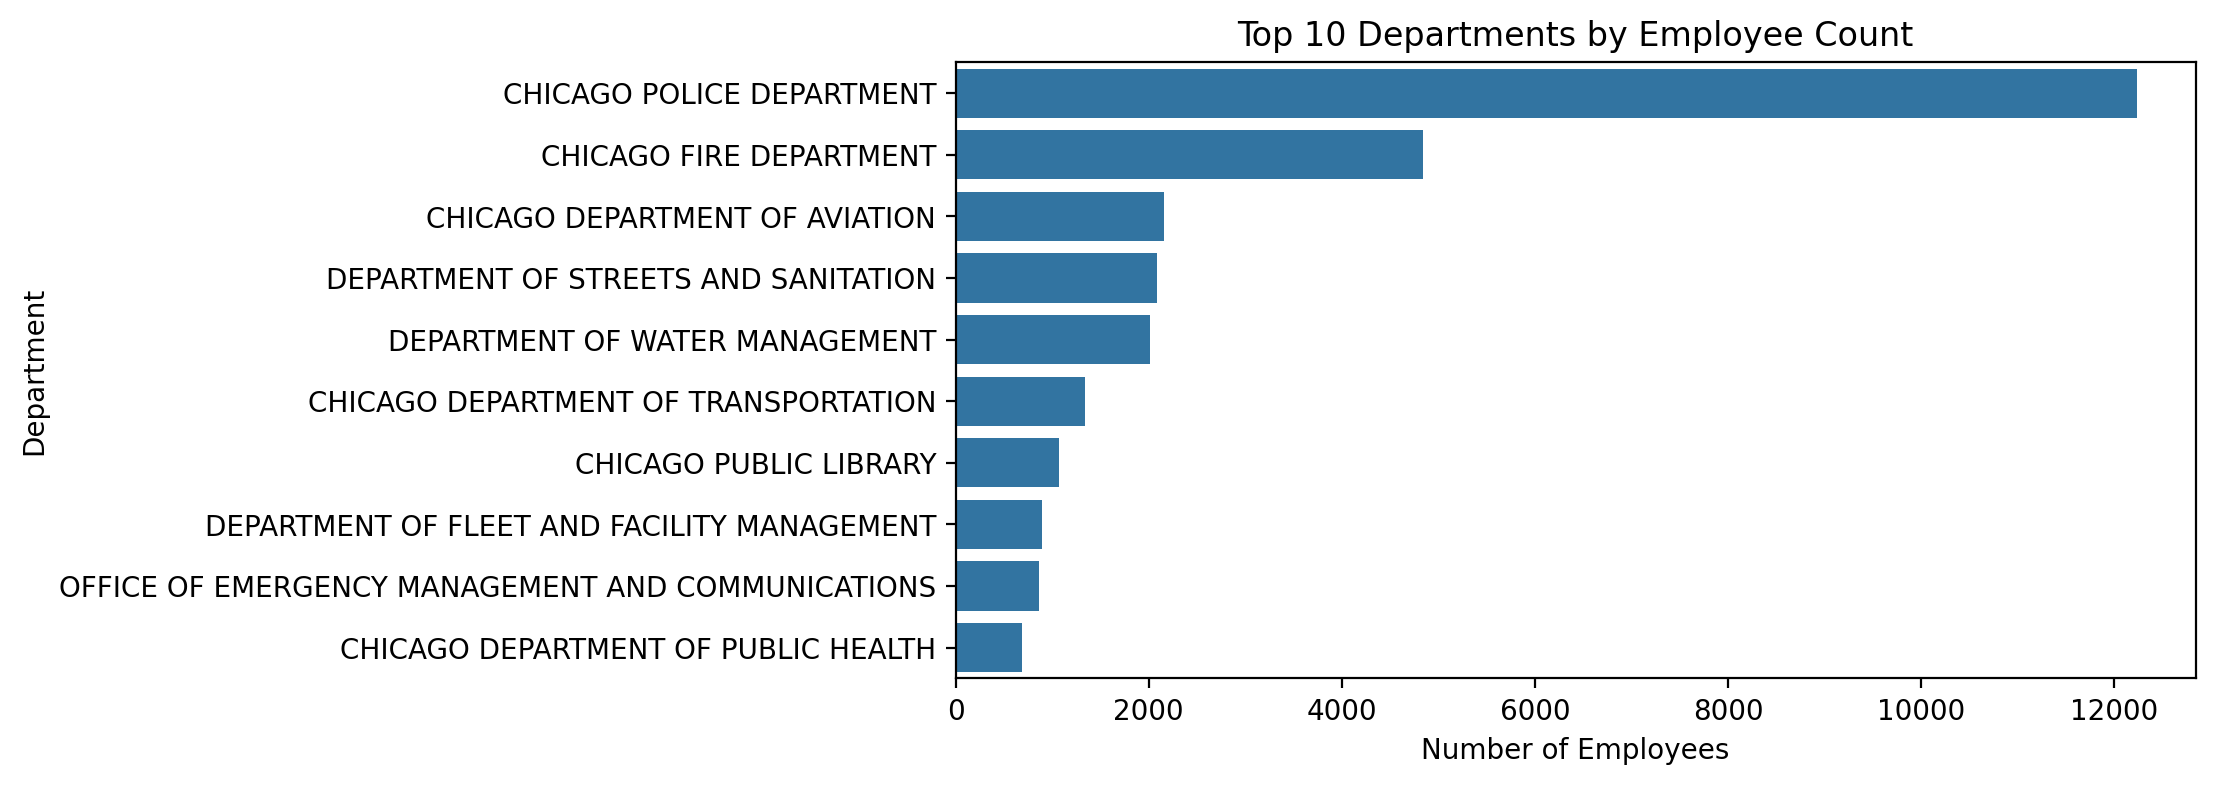

In [41]:
plt.figure(figsize=(8,4))
sns.barplot(x=df['Department'].value_counts().head(10).values,
            y=df['Department'].value_counts().head(10).index)
plt.title("Top 10 Departments by Employee Count")
plt.xlabel("Number of Employees")
plt.ylabel("Department")
plt.show()

## Full or Part Time

In [44]:
df['Full or Part-Time'].isna().sum()  # delete the null data in the end

np.int64(3)

In [145]:
# delete rows contain null data for Full or Part Time in the end
df[df['Full or Part-Time'].isna()][['Name', 'Job Titles', 'Department', 'Salary or Hourly', 'Annual Salary', 'Hourly Rate']]

,Name,Job Titles,Department,Salary or Hourly,Annual Salary,Hourly Rate
4114,"CARRANZA, ALISON",STUDENT INTERN,DEPARTMENT OF BUILDINGS,HOURLY,NaN,$16.60
4652,"CHAPMAN, DEVON",STUDENT INTERN - MAYOR'S FELLOWS,OFFICE OF THE MAYOR,HOURLY,NaN,$22.00
30893,"WHITE, LONDON J",ASST TO THE CITY TREASURER,CITY TREASURER'S OFFICE,SALARY,"$68,232.00",NaN


In [45]:
df['Full or Part-Time'].value_counts()

Full or Part-Time
F    31241
P     1034
Name: count, dtype: int64

In [46]:
df['Full or Part-Time'].value_counts(normalize=True)*100

Full or Part-Time
F    96.796282
P     3.203718
Name: proportion, dtype: float64

## Salary or Hourly

In [47]:
df['Salary or Hourly'].isna().sum()

np.int64(0)

In [49]:
df['Salary or Hourly'].value_counts()

Salary or Hourly
SALARY    25020
HOURLY     7258
Name: count, dtype: int64

In [50]:
df['Salary or Hourly'].value_counts(normalize=True)*100

Salary or Hourly
SALARY    77.514096
HOURLY    22.485904
Name: proportion, dtype: float64

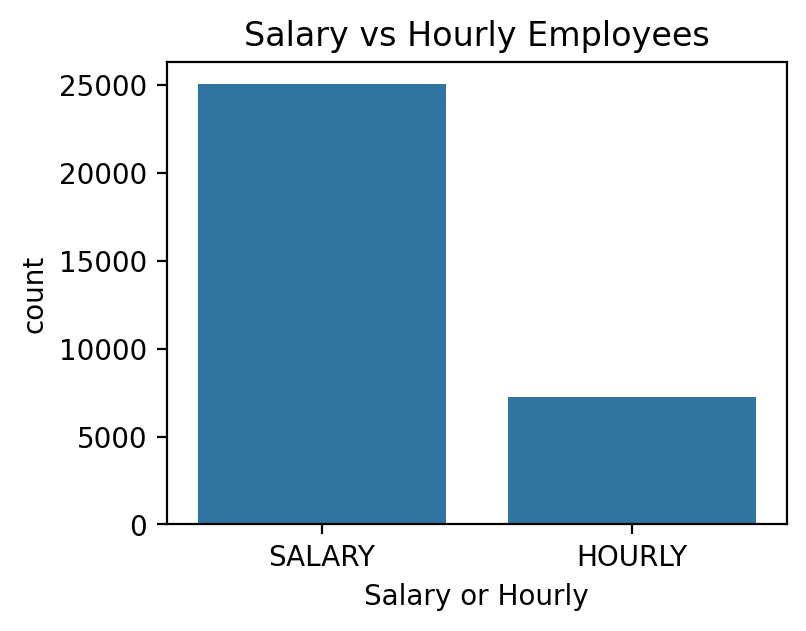

In [51]:
plt.figure(figsize=(4,3))
sns.countplot(x='Salary or Hourly', data=df)
plt.title("Salary vs Hourly Employees")
plt.show()

## Typical Hours

In [52]:
df['Typical Hours'].isna().sum()   # null data for people who get annual salary

np.int64(25020)

In [53]:
df['Typical Hours'].describe()

count    7258.000000
mean       37.051529
std         7.222451
min        10.000000
25%        40.000000
50%        40.000000
75%        40.000000
max        40.000000
Name: Typical Hours, dtype: float64

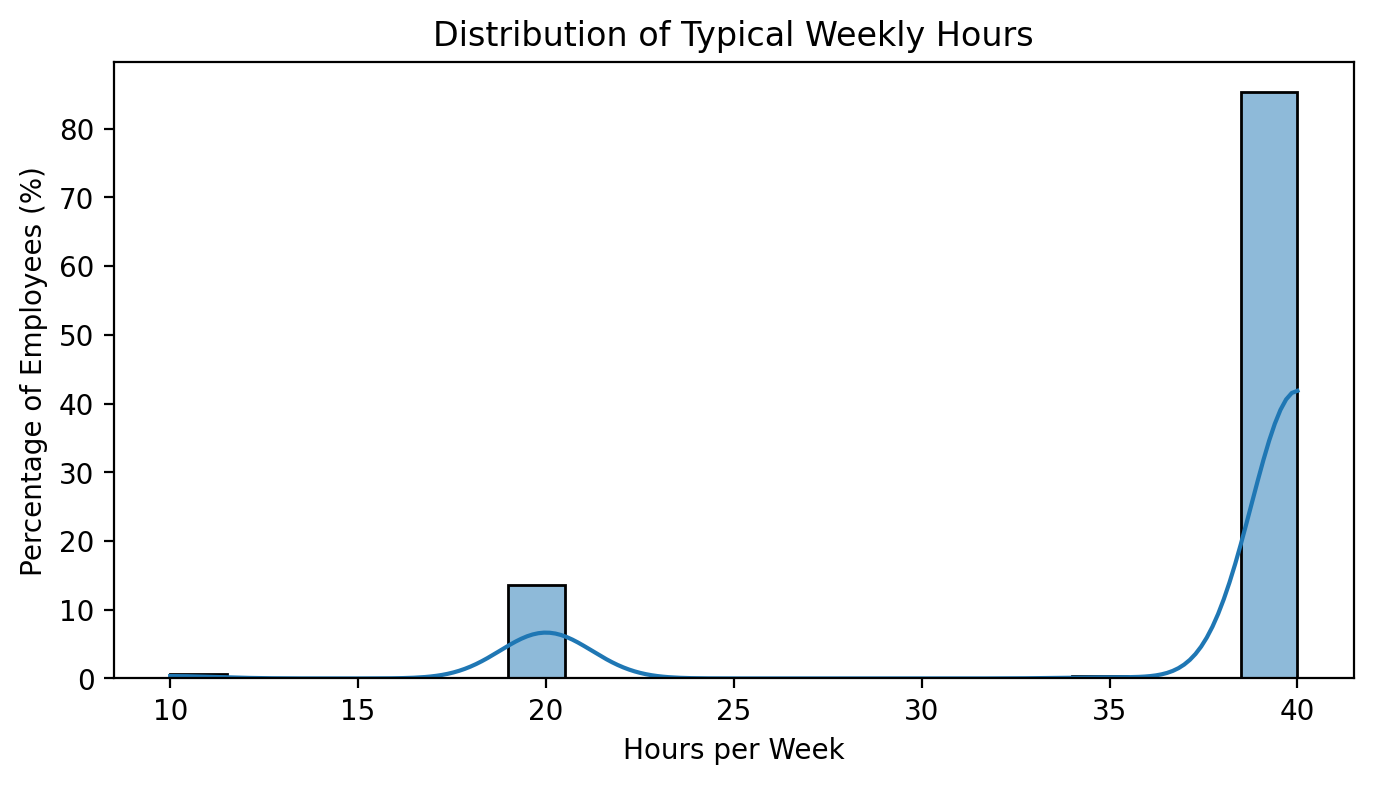

In [86]:
plt.figure(figsize=(8,4))
sns.histplot(df['Typical Hours'], bins=20, kde=True, stat="percent")
plt.title("Distribution of Typical Weekly Hours")
plt.xlabel("Hours per Week")
plt.ylabel("Percentage of Employees (%)")
plt.show()

## Annual Salary

In [59]:
df['Annual Salary'].isna().sum()   # null data for hourly employees

np.int64(7258)

In [60]:
df['Annual Salary'].describe()

count     25020.000000
mean     109023.199597
std       26917.793411
min       34176.000000
25%       93252.000000
50%      108012.000000
75%      123444.000000
max      350000.040000
Name: Annual Salary, dtype: float64

In [115]:
# job and department with lowest annual salary
lowest_salary = df.nsmallest(10, 'Annual Salary')[['Name', 'Job Titles', 'Department', 'Annual Salary']]
display(lowest_salary)

,Name,Job Titles,Department,Annual Salary
28790,"TOBY BROWN, CHIQUITA S",CLERK - BD OF ELECTIONS,BOARD OF ELECTION COMMISSIONERS,34176.0
11187,"GUY, ONEAL",LEGISLATIVE AIDE,CITY COUNCIL,35028.0
23042,"PRUITT, AKI",CLERK - BD OF ELECTIONS,BOARD OF ELECTION COMMISSIONERS,36804.0
293,"AHMED, NOREEN",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
1954,"BEAUCHAMP, ALIYAH",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
9553,"GARCIA, BEKI M",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
10199,"GODBOLD, JAYDEN G",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
12747,"HOSKINS, SHEIRTINA",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
14103,"JONES, IMANI",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
26894,"SKUBY, JESSICA E",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0


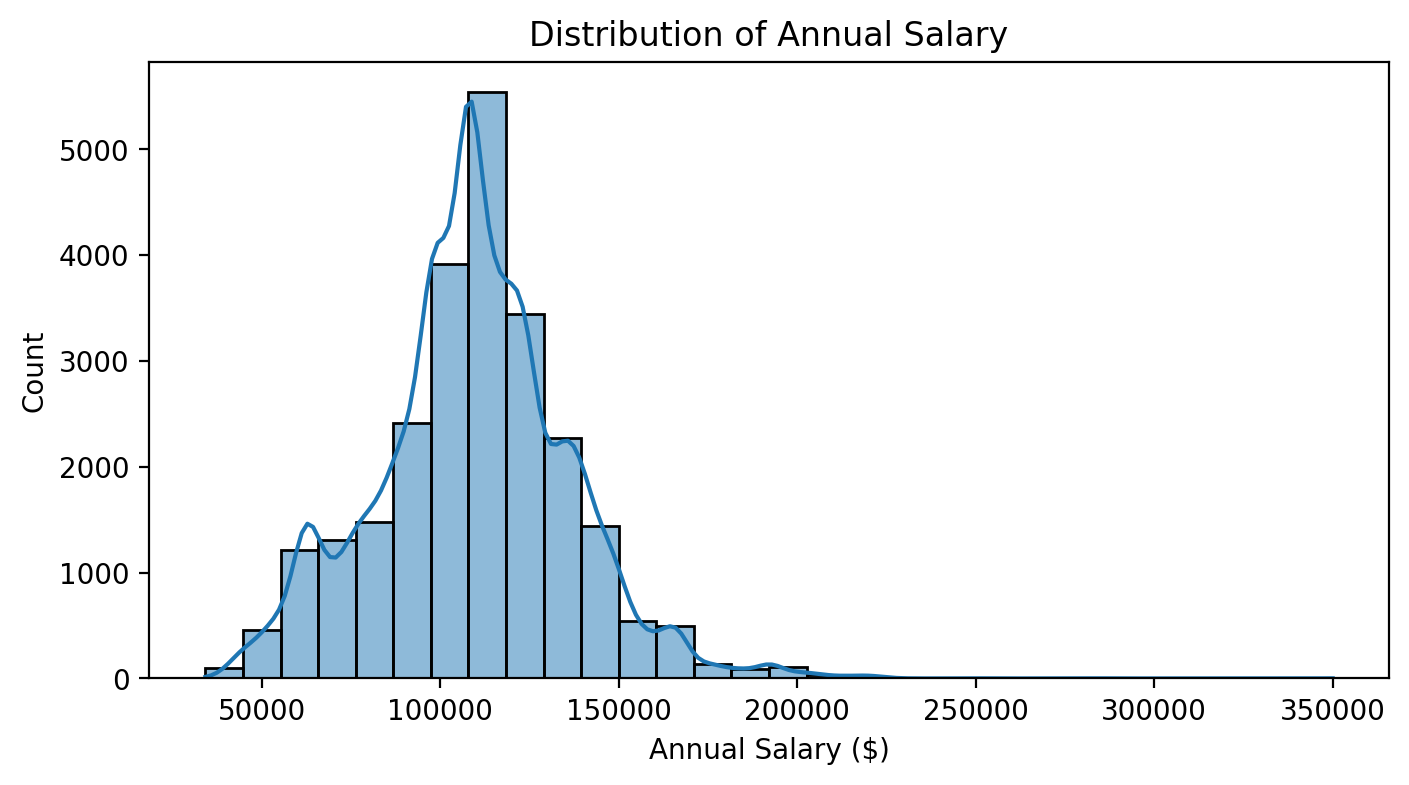

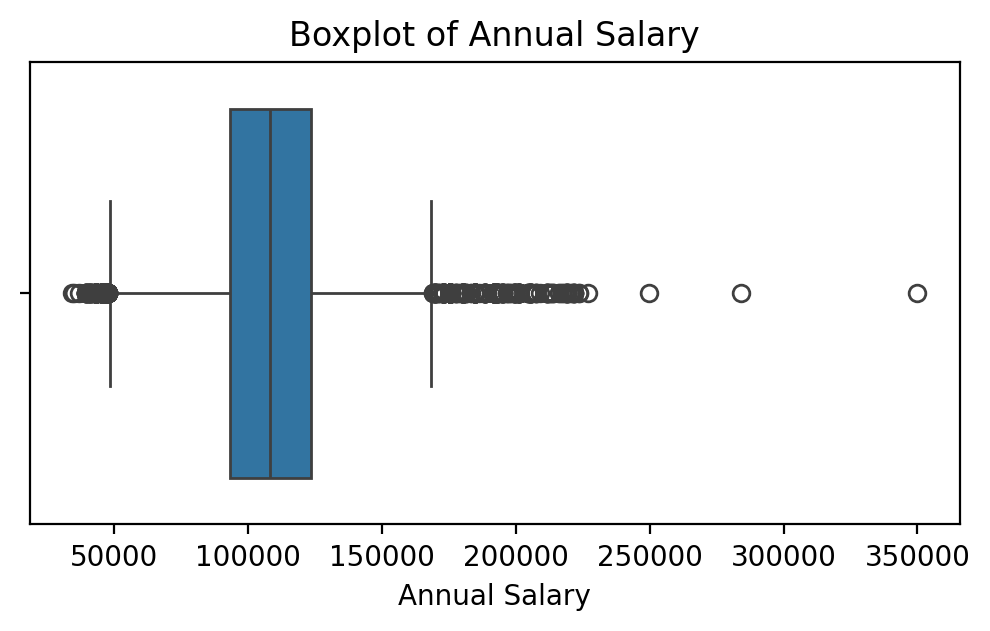

In [90]:
plt.figure(figsize=(8,4))
sns.histplot(df['Annual Salary'], bins=30, kde=True)
plt.title("Distribution of Annual Salary")
plt.xlabel("Annual Salary ($)")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['Annual Salary'])
plt.title("Boxplot of Annual Salary")
plt.show()

In [89]:
# Top10 highest paied employees (by Annual salary)
df.nlargest(10, 'Annual Salary')[['Name', 'Job Titles', 'Department', 'Annual Salary']]

,Name,Job Titles,Department,Annual Salary
18388,"MC MURRAY, MICHAEL J",COMMISSIONER OF AVIATION,CHICAGO DEPARTMENT OF AVIATION,350000.04
27240,"SNELLING, LARRY B",SUPERINTENDENT OF POLICE,CHICAGO POLICE DEPARTMENT,284016.00
20163,"NANCE HOLT, ANNETTE M",FIRE COMMISSIONER,CHICAGO FIRE DEPARTMENT,249780.00
14577,"KELLER, BRANDON M",FIRST DEPUTY FIRE COMMISSIONER,CHICAGO FIRE DEPARTMENT,226872.00
3092,"BROWN, CHRISTOPHER M",COMMISSIONER OF CHICAGO PUBLIC LIBRARY,CHICAGO PUBLIC LIBRARY,223740.00
21879,"PATTERSON, ERA R",EXEC DIR - OFFICE OF PUBLIC SAFETY ADM,OFFICE OF PUBLIC SAFETY ADMINISTRATION,223740.00
11948,"HELMOLD, BRIAN",DEPUTY FIRE COMMISSIONER,CHICAGO FIRE DEPARTMENT,221796.00
12303,"HERRING, CYNTHIA",DEPUTY FIRE COMMISSIONER,CHICAGO FIRE DEPARTMENT,221796.00
30247,"WALKER, DONALD L",DEPUTY FIRE COMMISSIONER,CHICAGO FIRE DEPARTMENT,221796.00
21108,"O'MALLEY, DANA M",SUPERINTENDENT'S CHIEF OF STAFF,CHICAGO POLICE DEPARTMENT,221652.00


In [121]:
# low annual salary
low_salary = df[df['Annual Salary'] < 50000][['Name', 'Job Titles', 'Department', 'Annual Salary']]
low_salary

,Name,Job Titles,Department,Annual Salary
24,"ABERO, AARON",PARKING ENFORCEMENT AIDE,DEPARTMENT OF FINANCE,47628.0
211,"AGREDANO, SALENA",INQUIRY AIDE III,CHICAGO POLICE DEPARTMENT,47436.0
293,"AHMED, NOREEN",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
321,"AKINJIYAN, OMOTAYO O",WATER QUALITY INSPECTOR,DEPARTMENT OF WATER MANAGEMENT,47436.0
465,"ALFRED, JERRELL J",PARKING ENFORCEMENT AIDE,DEPARTMENT OF FINANCE,49848.0
...,...,...,...,...
31889,"YOUNG, CASHARA A",TRAFFIC ENFORCEMENT TECH,DEPARTMENT OF FINANCE,39384.0
31919,"YOUNG, RAKYIAH",PARKING ENFORCEMENT AIDE,DEPARTMENT OF FINANCE,45456.0
31962,"ZABEL, SHERRY",CLERK - BD OF ELECTIONS,BOARD OF ELECTION COMMISSIONERS,45948.0
32022,"ZAMORA, ROBERTO",PARKING ENFORCEMENT AIDE,DEPARTMENT OF FINANCE,47628.0


In [126]:
low_salary_jobs = (low_salary.groupby(['Job Titles'])['Name']
                   .count()
                   .reset_index(name='Count')
                   .sort_values('Count', ascending=False)
                   .head(10))
display(low_salary_jobs)

low_salary_dept = (low_salary.groupby(['Department'])['Name']
                   .count()
                   .reset_index(name='Count')
                   .sort_values('Count', ascending=False)
                   .head(10))
display(low_salary_dept)

,Job Titles,Count
7,LIBRARY CLERK,77
9,PARKING ENFORCEMENT AIDE,48
19,TRAFFIC ENFORCEMENT TECH,30
2,CLERK - BD OF ELECTIONS,25
15,SENIOR OFFICE ASSISTANT,23
18,TRAFFIC CONTROL AIDE,15
16,STAFF ASST TO THE ALDERMAN,9
5,INQUIRY AIDE III,5
13,SENIOR CLERK-ELECTIONS,4
3,ELECTION EQUIPMENT & SUPPLY SPEC I,4


,Department,Count
7,DEPARTMENT OF FINANCE,80
4,CHICAGO PUBLIC LIBRARY,79
0,BOARD OF ELECTION COMMISSIONERS,38
11,OFFICE OF EMERGENCY MANAGEMENT AND COMMUNICATIONS,15
2,CHICAGO DEPARTMENT OF PUBLIC HEALTH,14
5,CITY COUNCIL,11
9,DEPARTMENT OF STREETS AND SANITATION,6
10,DEPARTMENT OF WATER MANAGEMENT,4
1,CHICAGO DEPARTMENT OF AVIATION,4
6,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,4


In [124]:
# high annual salary
high_salary = df[df['Annual Salary'] > 170000][['Name', 'Job Titles', 'Department', 'Annual Salary']]
high_salary

,Name,Job Titles,Department,Annual Salary
93,"ACHARYA, SNIGDHA",GENERAL COUNSEL,CHICAGO DEPARTMENT OF PUBLIC HEALTH,186156.0
95,"ACHILLES, AMBER L",MANAGING DEPUTY COMMISSIONER - 41,CHICAGO DEPARTMENT OF AVIATION,211752.0
292,"AHMED, NAFEES",DEPUTY COMMISSIONER - 42,CHICAGO DEPARTMENT OF AVIATION,192852.0
402,"ALDERDEN, JACOB M",CAPTAIN,CHICAGO POLICE DEPARTMENT,175908.0
445,"ALEXANDER, SAMUEL M",MANAGING DEPUTY COMMISSIONER - 41,CHICAGO DEPARTMENT OF TRANSPORTATION,184800.0
...,...,...,...,...
31716,"WRIGHT, CHARLES A",GENERAL COUNSEL,COMMUNITY COMMISSION FOR PUBLIC SAFETY AND ACC...,175512.0
31973,"ZAENTZ, JONATHAN A",DISTRICT CHIEF,CHICAGO FIRE DEPARTMENT,205560.0
32137,"ZEPEDA, LUIS",FIRST DEPUTY COMMISSIONER - 41,DEPARTMENT OF STREETS AND SANITATION,211752.0
32148,"ZHANG, ANNE",DEPUTY COMMISSIONER - 42,CHICAGO DEPARTMENT OF TRANSPORTATION,184584.0


In [125]:
high_salary_jobs = (high_salary.groupby(['Job Titles'])['Name']
                    .count()
                    .reset_index(name='Count')
                    .sort_values('Count', ascending=False)
                    .head(10))
display(high_salary_jobs)

high_salary_dept = (high_salary.groupby(['Department'])['Name']
                    .count()
                    .reset_index(name='Count')
                    .sort_values('Count', ascending=False)
                    .head(10))
display(high_salary_dept)

,Job Titles,Count
47,DEPUTY COMMISSIONER - 42,40
23,COMMANDER,36
8,CAPTAIN,31
11,CHIEF ASST CORPORATION COUNSEL,17
49,DEPUTY CORPORATION COUNSEL,17
52,DEPUTY DISTRICT CHIEF,17
50,DEPUTY DIR,16
42,DEPUTY CHIEF,14
92,MANAGING DEPUTY COMMISSIONER - 41,14
46,DEPUTY COMMISSIONER,13


,Department,Count
5,CHICAGO POLICE DEPARTMENT,102
4,CHICAGO FIRE DEPARTMENT,51
19,DEPARTMENT OF LAW,41
1,CHICAGO DEPARTMENT OF AVIATION,24
15,DEPARTMENT OF FINANCE,19
30,OFFICE OF THE MAYOR,16
2,CHICAGO DEPARTMENT OF PUBLIC HEALTH,15
24,DEPARTMENT OF WATER MANAGEMENT,15
3,CHICAGO DEPARTMENT OF TRANSPORTATION,12
29,OFFICE OF PUBLIC SAFETY ADMINISTRATION,9


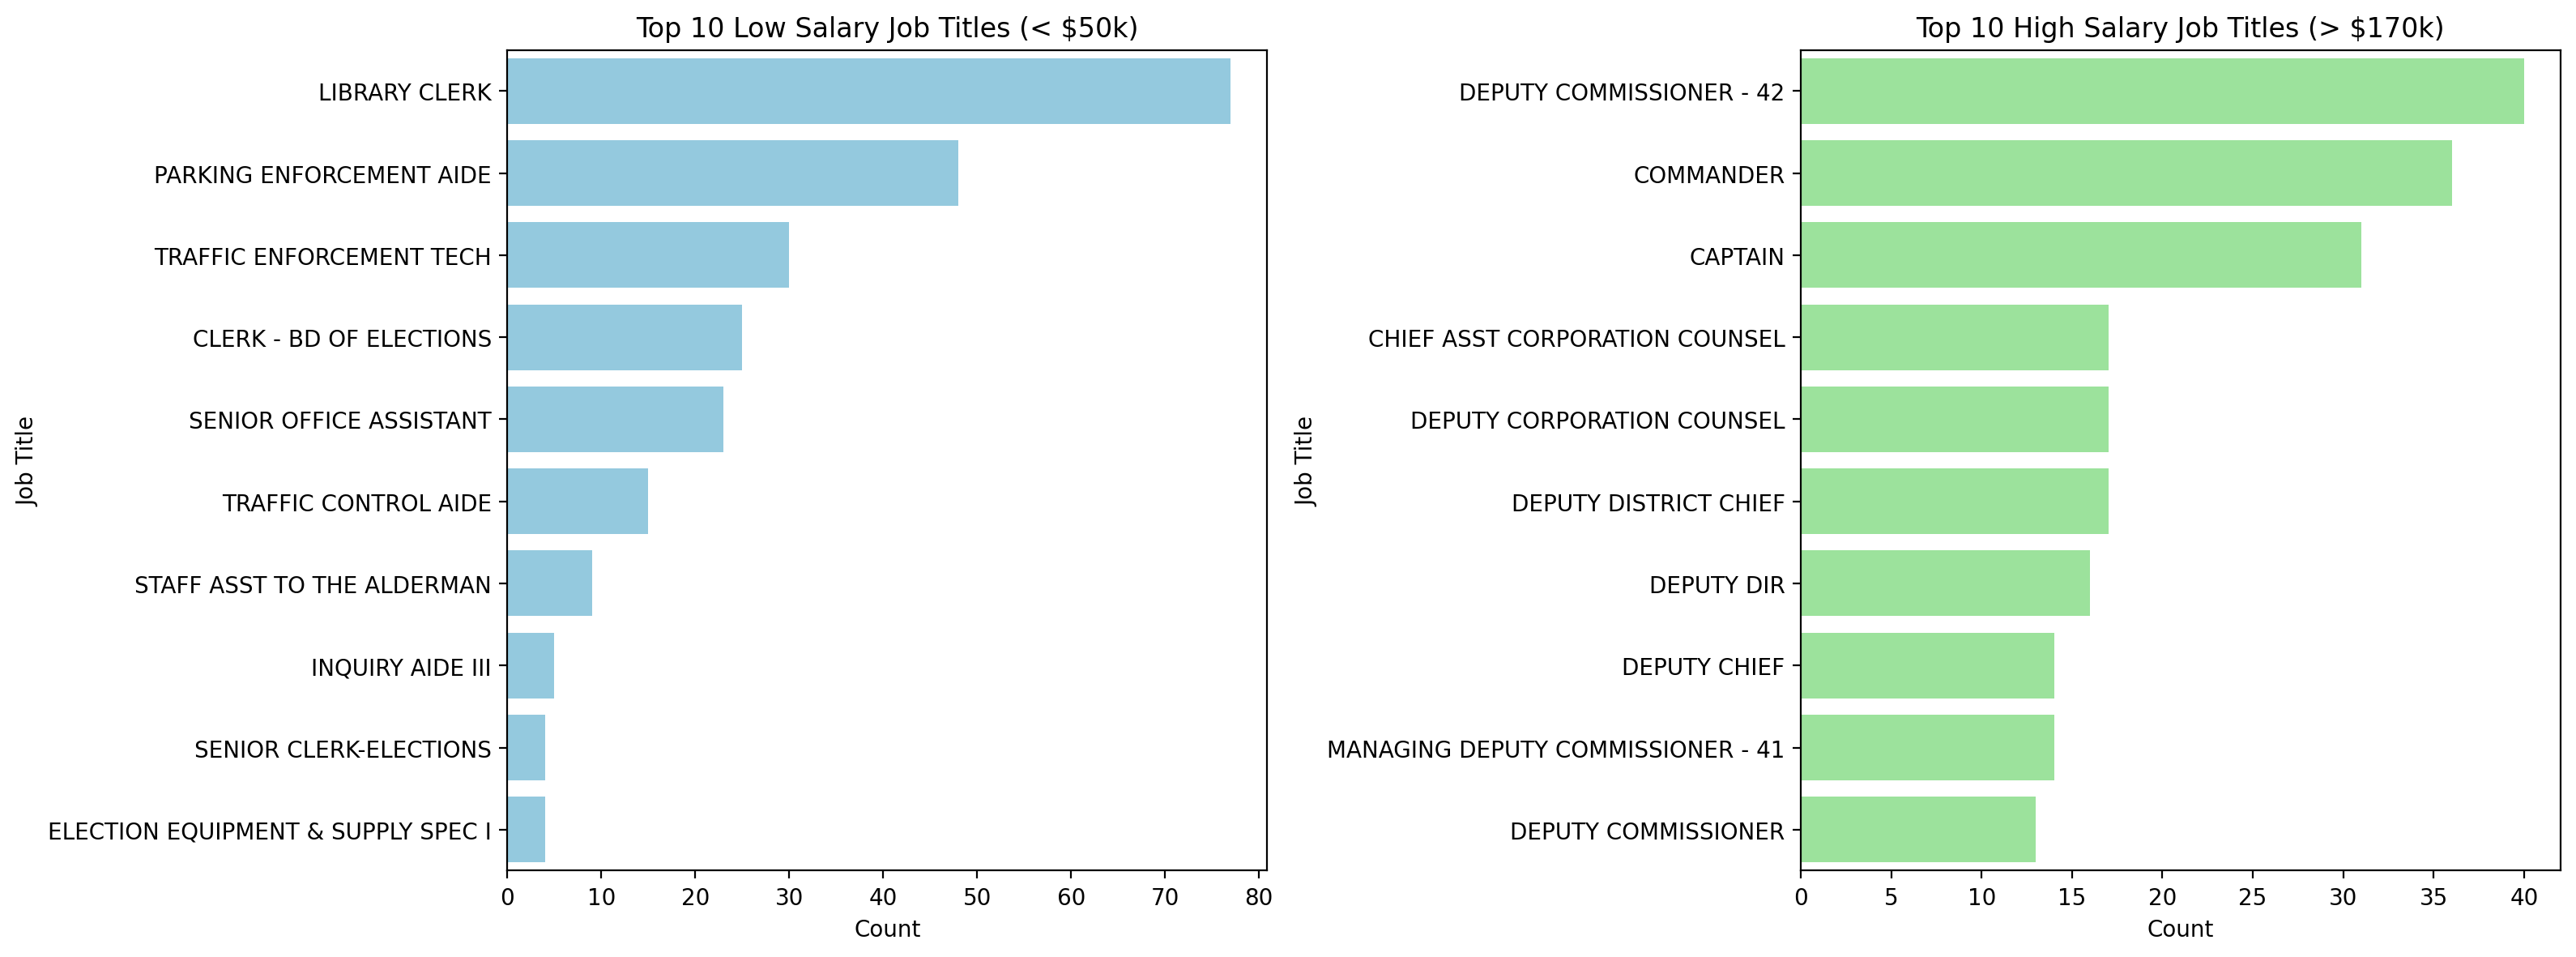

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=low_salary_jobs, y='Job Titles', x='Count', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Low Salary Job Titles (< $50k)')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Job Title')

sns.barplot(data=high_salary_jobs, y='Job Titles', x='Count', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 High Salary Job Titles (> $170k)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Job Title')

plt.tight_layout()
plt.show()

## Hourly Rate

In [71]:
df['Hourly Rate'].isna().sum()  # null data for people who get hourly pay

np.int64(25020)

In [72]:
df['Hourly Rate'].describe()

count    7258.000000
mean       45.868633
std        14.564218
min         4.000000
25%        43.010000
50%        48.730000
75%        54.300000
max        70.870000
Name: Hourly Rate, dtype: float64

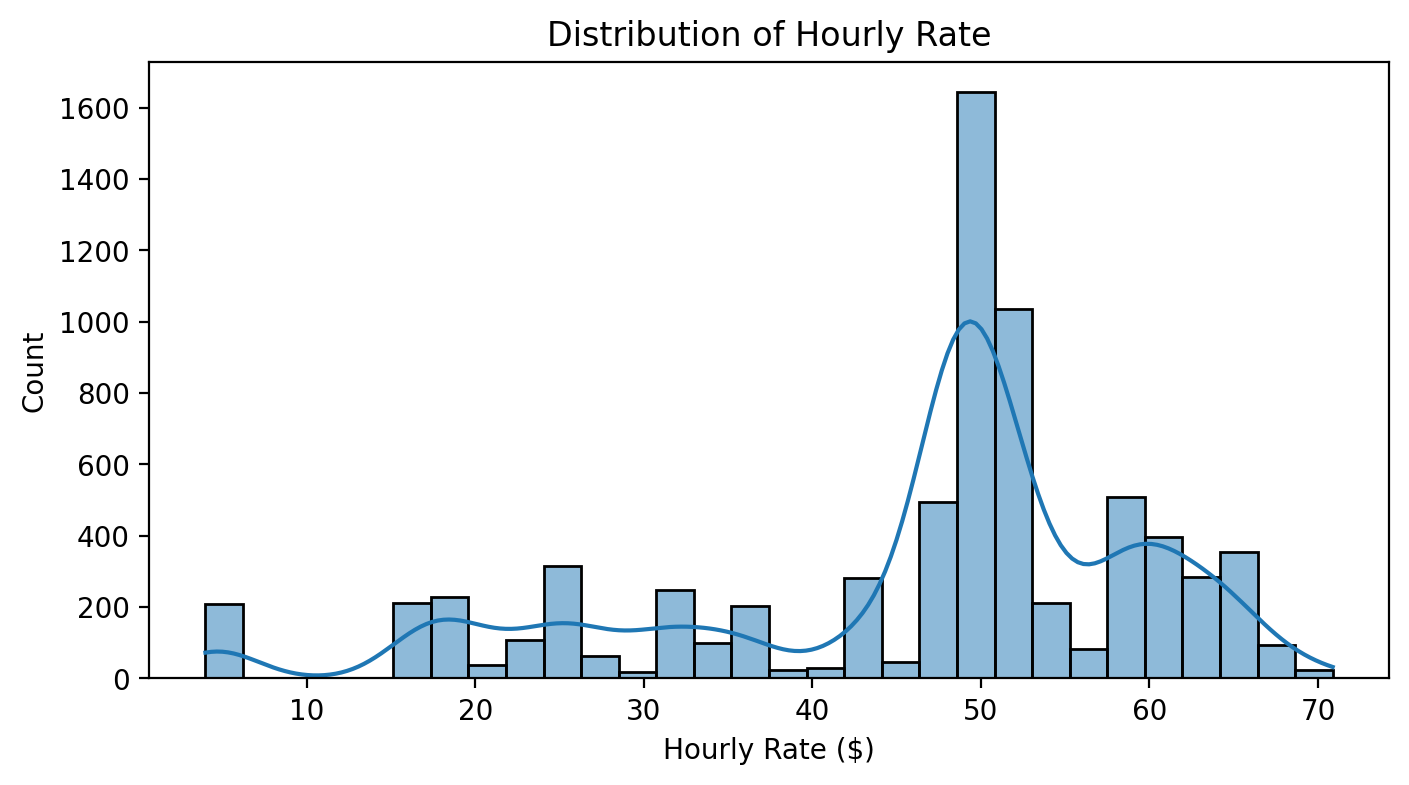

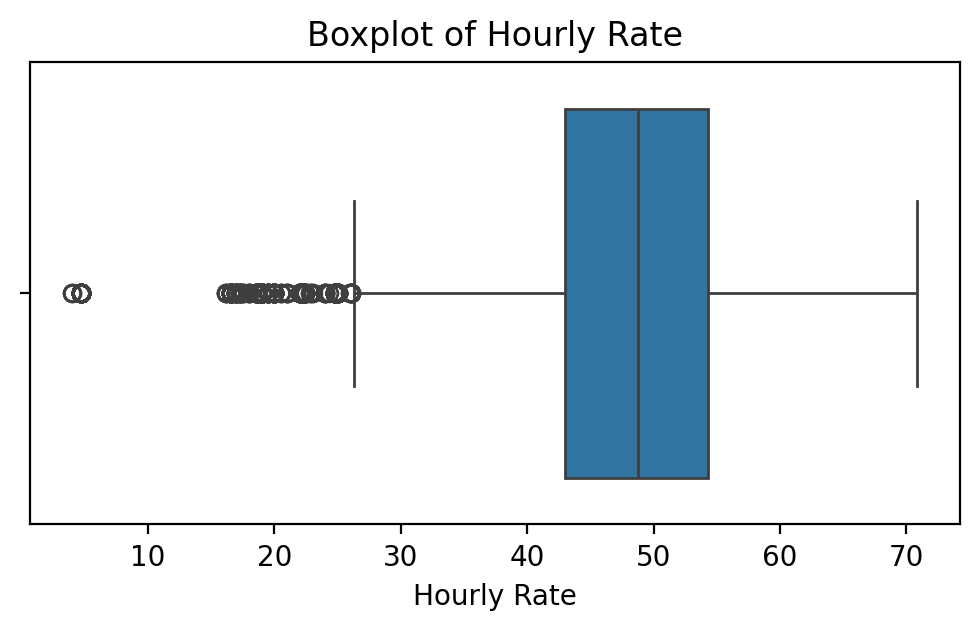

In [69]:
plt.figure(figsize=(8,4))
sns.histplot(df['Hourly Rate'], bins=30, kde=True)
plt.title("Distribution of Hourly Rate")
plt.xlabel("Hourly Rate ($)")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['Hourly Rate'])
plt.title("Boxplot of Hourly Rate")
plt.show()

In [21]:
# Top10 highest paied employees (by Hourly rate)
df.nlargest(10, 'Hourly Rate')[['Name', 'Job Titles', 'Department', 'Hourly Rate']]

,Name,Job Titles,Department,Hourly Rate
1097,"ARMSTRONG, MARCUS",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
1842,"BARZOLA, FRANCISCO",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
13001,"HUNT, BARNEY F",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
14854,"KING, BRYAN A",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
16070,"LEWIS, TROY",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
17898,"MCCALL, DANIEL W",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
18265,"MCKENNA, DANIEL C",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
18900,"MILLER, ADAM M",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
19074,"MISHER, MARIO",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
20188,"NARDUCY, MICHELLE",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87


In [92]:
# What kind of job or department has higher hourly rate?
high_hourly = df[df['Hourly Rate'] > 60][['Name', 'Job Titles', 'Department', 'Hourly Rate']]
high_hourly

,Name,Job Titles,Department,Hourly Rate
54,"ABUHASHISH, AWWAD",FOREMAN OF WATER PIPE CONSTRUCTION,DEPARTMENT OF WATER MANAGEMENT,64.15
68,"ACEVEDO, BRANDON L",MACHINIST (AUTOMOTIVE),DEPARTMENT OF FLEET AND FACILITY MANAGEMENT,60.39
107,"ACOSTA, JORGE L",MACHINIST,DEPARTMENT OF WATER MANAGEMENT,60.39
124,"ADAME, JORGE A",MACHINIST (AUTOMOTIVE),DEPARTMENT OF FLEET AND FACILITY MANAGEMENT,60.39
131,"ADAMS, DARREN",PLUMBER,DEPARTMENT OF WATER MANAGEMENT,60.50
...,...,...,...,...
32220,"ZOLTEK, JOHN J",FRM OF ELECTRICAL MECHANICS (AUTO),DEPARTMENT OF FLEET AND FACILITY MANAGEMENT,63.53
32227,"ZOVKO, RICHARD A",HOISTING ENGINEER - MECHANIC,DEPARTMENT OF FLEET AND FACILITY MANAGEMENT,67.80
32230,"ZUBECK, JOHN",PLUMBER,DEPARTMENT OF WATER MANAGEMENT,60.50
32232,"ZUCKER, MICHAEL J",MACHINIST (AUTOMOTIVE),DEPARTMENT OF FLEET AND FACILITY MANAGEMENT,60.39


In [93]:
high_hourly.sort_values('Hourly Rate', ascending=False).head(10)

,Name,Job Titles,Department,Hourly Rate
31836,"YAU, HENRY",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
1097,"ARMSTRONG, MARCUS",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
18900,"MILLER, ADAM M",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
19074,"MISHER, MARIO",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
20188,"NARDUCY, MICHELLE",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
21997,"PECA, CHRISTOPHE J",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
28828,"TOLEDO, RAMON",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
17898,"MCCALL, DANIEL W",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
26580,"SHIELDS, THOMAS S",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87
1842,"BARZOLA, FRANCISCO",FOREMAN OF LINEMEN,CHICAGO DEPARTMENT OF TRANSPORTATION,70.87


In [98]:
# departments with higher hourly rate
dept_highpay = (
    df[df['Hourly Rate'] > 60]
    .groupby('Department')['Name']
    .count()
    .reset_index(name='Num_Employees_Over_60')
    .sort_values('Num_Employees_Over_60', ascending=False)
)

dept_highpay

,Department,Num_Employees_Over_60
5,DEPARTMENT OF WATER MANAGEMENT,462
3,DEPARTMENT OF FLEET AND FACILITY MANAGEMENT,349
1,CHICAGO DEPARTMENT OF TRANSPORTATION,161
0,CHICAGO DEPARTMENT OF AVIATION,86
4,DEPARTMENT OF STREETS AND SANITATION,36
6,OFFICE OF PUBLIC SAFETY ADMINISTRATION,14
2,CITY COUNCIL,1


In [22]:
# jobs with higher hourly rate
job_highpay = (
    df[df['Hourly Rate'] > 60]
    .groupby('Job Titles')['Name']
    .count()
    .reset_index(name='Num_Employees_Over_60')
    .sort_values('Num_Employees_Over_60', ascending=False)
)

job_highpay.head(10)

,Job Titles,Num_Employees_Over_60
20,HOISTING ENGINEER,259
27,OPERATING ENGINEER-GROUP A,192
24,MACHINIST (AUTOMOTIVE),173
29,PLUMBER,132
1,ASST CHIEF OPERATING ENGINEER,64
22,LINEMAN,58
23,MACHINIST,36
21,HOISTING ENGINEER - MECHANIC,29
7,FOREMAN OF ELECTRICAL MECHANICS,28
18,FRM OF MACHINISTS - AUTOMOTIVE,24


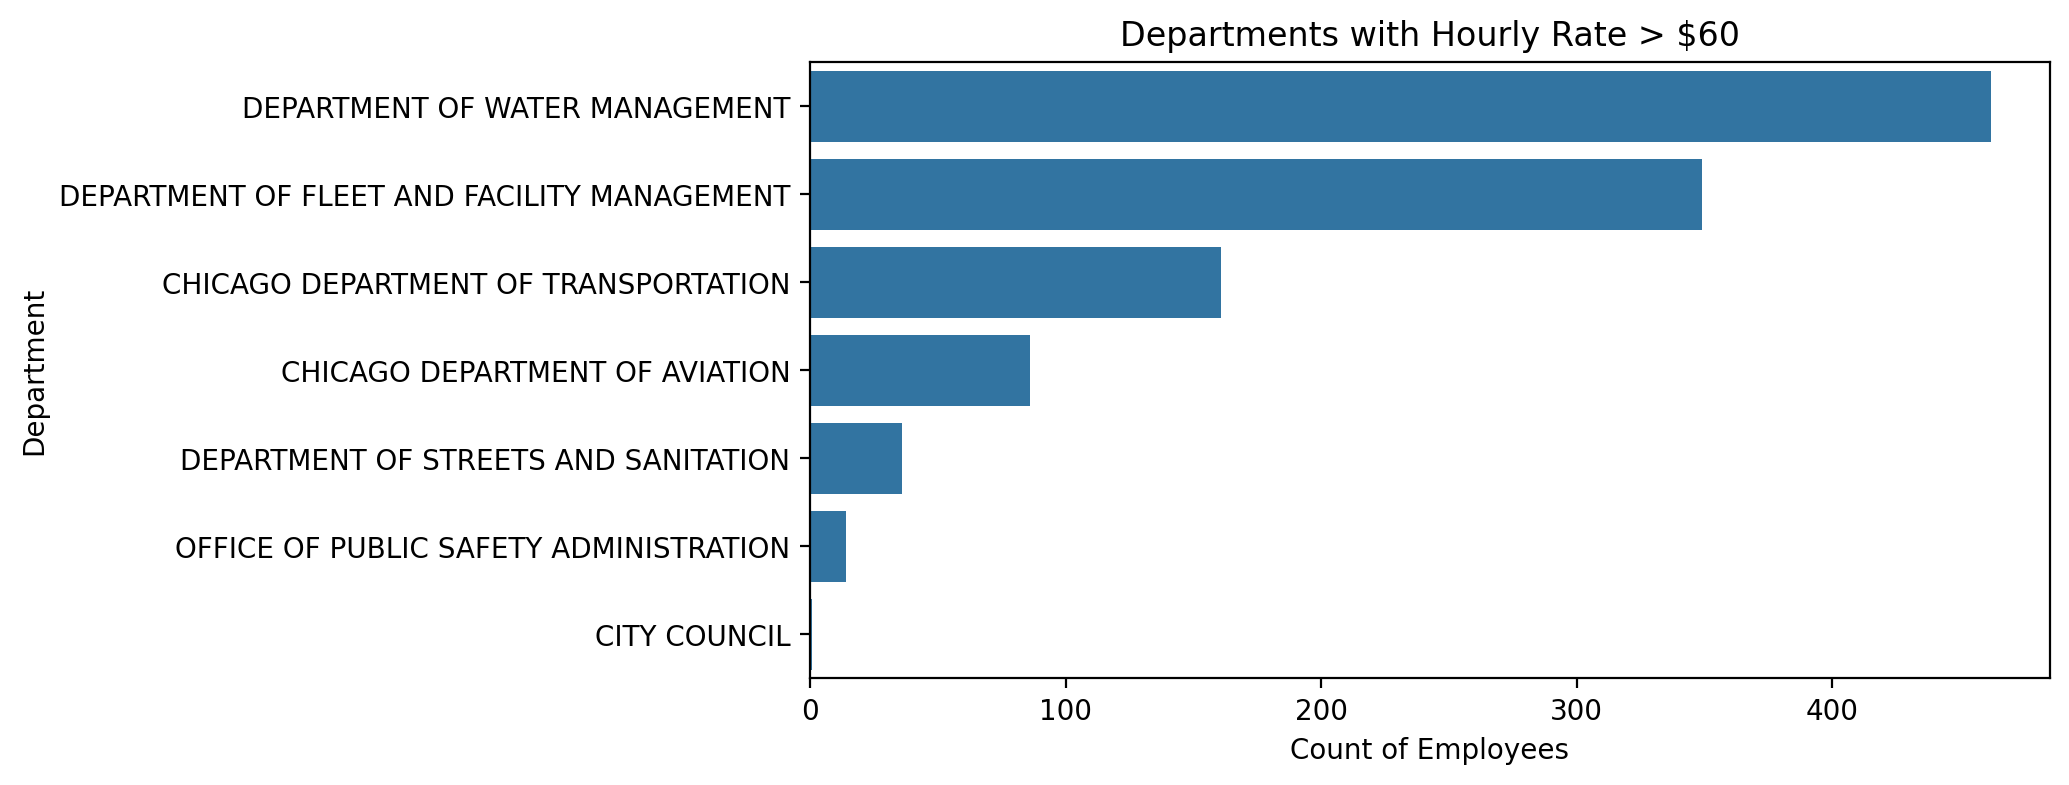

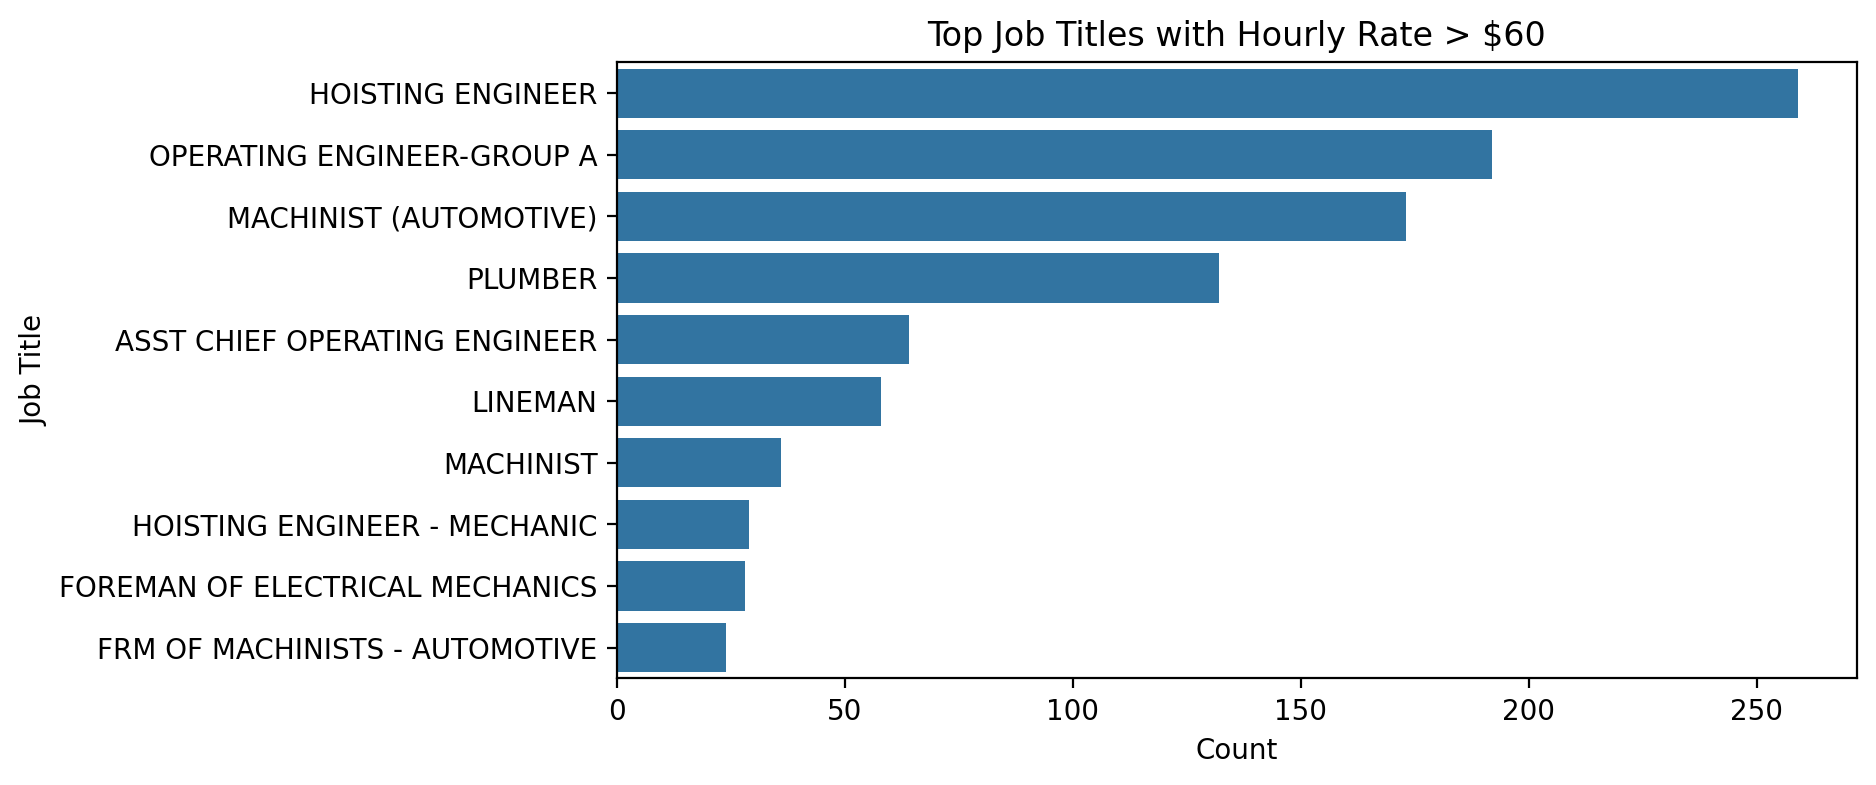

In [94]:
plt.figure(figsize=(8,4))
sns.countplot(y='Department', data=high_hourly, order=high_hourly['Department'].value_counts().index)
plt.title("Departments with Hourly Rate > $60")
plt.xlabel("Count of Employees")
plt.ylabel("Department")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(y='Job Titles', data=high_hourly, order=high_hourly['Job Titles'].value_counts().head(10).index)
plt.title("Top Job Titles with Hourly Rate > $60")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

In [23]:
# check very low hourly rate
low_hourly = df[df['Hourly Rate'] < 10][['Name', 'Job Titles', 'Department','Full or Part-Time', 'Typical Hours', 'Hourly Rate']]
low_hourly.shape[0]

209

In [112]:
low_hourly

,Name,Job Titles,Department,Full or Part-Time,Typical Hours,Hourly Rate
7,"ABBOTT, BETTY L",FOSTER GRANDPARENT,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
104,"ACOSTA, HECTOR",FOSTER GRANDPARENT,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
156,"ADAMS, RENA M",FOSTER GRANDPARENT,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
173,"ADEBIMPE, VENISE A",SENIOR COMPANION,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
334,"AL AMIN, RASHEEDAH K",SENIOR COMPANION,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
...,...,...,...,...,...,...
31767,"WU, JIN H",SENIOR COMPANION,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
31830,"YASHCENKO, LARISA V",SENIOR COMPANION,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
31855,"YE, SONG D",SENIOR COMPANION,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73
31950,"YU, MING Z",SENIOR COMPANION,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,20.0,4.73


In [24]:
# These two jobs belong to Federal Volunteer Programs that provide a fixed stipend rather than wages. Consider to delete them if analyzing the salaries for actual employment roles.
low_hourly_jobs = (
    low_hourly.groupby('Job Titles')['Name']
    .count()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)
low_hourly_jobs

,Job Titles,Count
0,FOSTER GRANDPARENT,117
1,SENIOR COMPANION,92


In [136]:
df[df['Job Titles'].isin(['FOSTER GRANDPARENT', 'SENIOR COMPANION'])]['Hourly Rate'].describe()

count    209.000000
mean       4.719522
std        0.087039
min        4.000000
25%        4.730000
50%        4.730000
75%        4.730000
max        4.730000
Name: Hourly Rate, dtype: float64

In [138]:
df[df['Job Titles'].isin(['FOSTER GRANDPARENT', 'SENIOR COMPANION'])]['Department'].value_counts()
# All employees with these two job titles in this department have the lowest hourly rate of $4.73.
# So we can delete all these 209 rows.

Department
DEPARTMENT OF FAMILY AND SUPPORT SERVICES    209
Name: count, dtype: int64

Text(0, 0.5, 'Number of Employees')

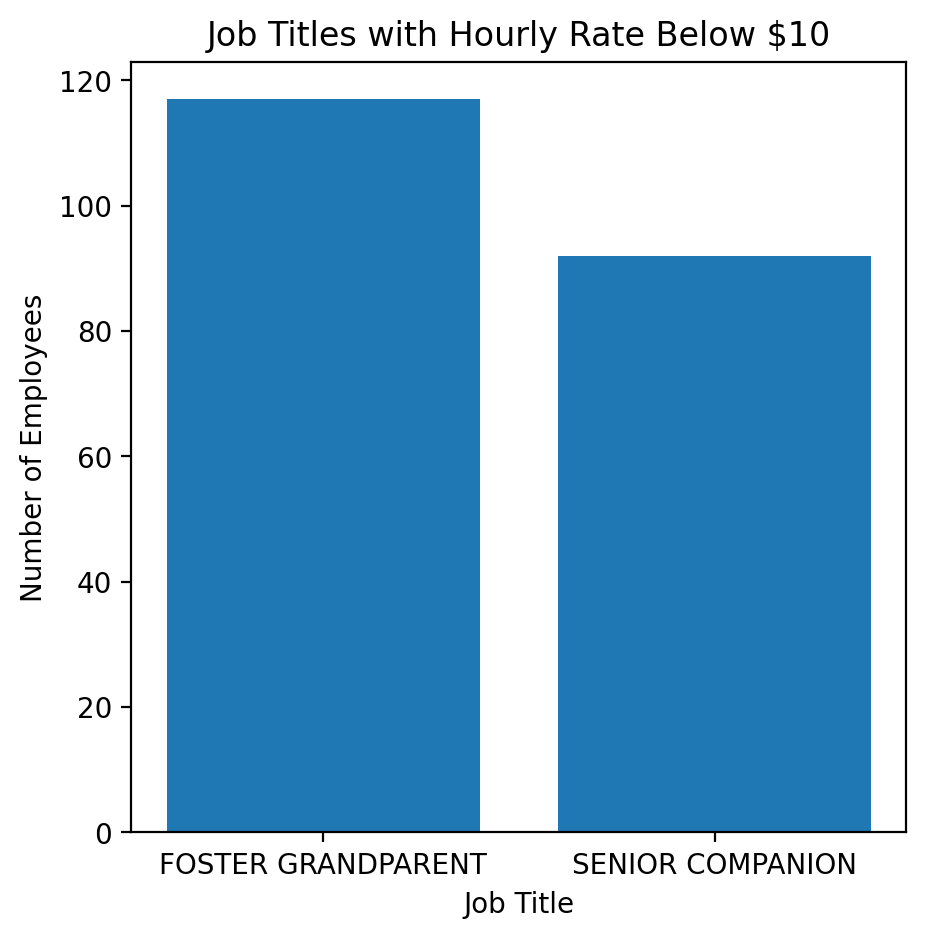

In [30]:
plt.figure(figsize=(5, 5))
plt.bar(low_hourly_jobs['Job Titles'], low_hourly_jobs['Count'])

plt.title('Job Titles with Hourly Rate Below $10', fontsize=12)
plt.xlabel('Job Title')
plt.ylabel('Number of Employees')

# Step 3: Construct clean data

In [165]:
df = pd.read_csv('Current_Employee_Names,_Salaries,_and_Position_Titles.csv')

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32278 entries, 0 to 32277
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               32278 non-null  object 
 1   Job Titles         32278 non-null  object 
 2   Department         32278 non-null  object 
 3   Full or Part-Time  32275 non-null  object 
 4   Salary or Hourly   32278 non-null  object 
 5   Typical Hours      7258 non-null   float64
 6   Annual Salary      25020 non-null  object 
 7   Hourly Rate        7258 non-null   object 
dtypes: float64(1), object(7)
memory usage: 2.0+ MB


In [167]:
# Change Annual Salary and Hourly Rate to numeric type
for col in ['Annual Salary', 'Hourly Rate']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[\$,]', '', regex=True)  # Remove symbols
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce') 

# Drop fully duplicated rows (keep the first occurrence)
before_dup = df.shape[0]
df = df.drop_duplicates()
after_dup = df.shape[0]
print(f"Removed {before_dup - after_dup} duplicate rows. ({after_dup} rows remain)")

# Drop rows with missing Full or Part-Time values
before_null = df.shape[0]
df = df.dropna(subset=['Full or Part-Time'])
after_null = df.shape[0]
print(f"Removed {before_null - after_null} rows with missing Full/Part-Time status. ({after_null} rows remain)")

# Remove volunteer program participants (Foster Grandparent & Senior Companion)
before_vol = df.shape[0]
df = df[~df['Job Titles'].isin(['FOSTER GRANDPARENT', 'SENIOR COMPANION'])]
after_vol = df.shape[0]
print(f"Removed {before_vol - after_vol} volunteer records. ({after_vol} rows remain)")

# Final shape
df.shape

Removed 11 duplicate rows. (32267 rows remain)
Removed 3 rows with missing Full/Part-Time status. (32264 rows remain)
Removed 209 volunteer records. (32055 rows remain)


(32055, 8)

In [169]:
import re

# Rename columns to Python-friendly snake_case
df.rename(columns={
    'Name': 'name',
    'Job Titles': 'job_titles',
    'Department': 'department',
    'Full or Part-Time': 'full_or_part_time',
    'Salary or Hourly': 'salary_or_hourly',
    'Typical Hours': 'typical_hours',
    'Annual Salary': 'annual_salary',
    'Hourly Rate': 'hourly_rate'
}, inplace=True)

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32055 entries, 0 to 32277
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               32055 non-null  object 
 1   job_titles         32055 non-null  object 
 2   department         32055 non-null  object 
 3   full_or_part_time  32055 non-null  object 
 4   salary_or_hourly   32055 non-null  object 
 5   typical_hours      7046 non-null   float64
 6   annual_salary      25009 non-null  float64
 7   hourly_rate        7046 non-null   float64
dtypes: float64(3), object(5)
memory usage: 2.2+ MB


In [171]:
df

,name,job_titles,department,full_or_part_time,salary_or_hourly,typical_hours,annual_salary,hourly_rate
0,"AARON, JEFFERY M",LIEUTENANT,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,160800.0,NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,136362.0,NaN
2,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,DEPARTMENT OF WATER MANAGEMENT,F,SALARY,NaN,137436.0,NaN
3,"ABARCA-COMPTON, RUTH A",ATTORNEY - EXCLUDED,CHICAGO DEPARTMENT OF PUBLIC HEALTH,F,SALARY,NaN,131124.0,NaN
4,"ABARCA, EMMANUEL",CONCRETE LABORER,CHICAGO DEPARTMENT OF TRANSPORTATION,F,HOURLY,40.0,NaN,51.4
...,...,...,...,...,...,...,...,...
32273,"ZYLINSKA JEDD, KLAUDIA",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,108012.0,NaN
32274,"ZYMANTAS, LAURA C",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,108012.0,NaN
32275,"ZYMANTAS, MARK E",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,119976.0,NaN
32276,"ZYRKOWSKI, CARLO E",POLICE OFFICER,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,123444.0,NaN


In [172]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
typical_hours,7046.0,37.559608,6.693773,10.0,40.00,40.00,40.0,40.00
annual_salary,25009.0,109025.278656,26921.024890,34176.0,93252.00,108012.00,123444.0,350000.04
hourly_rate,7046.0,47.094688,12.904682,16.2,43.86,48.73,55.1,70.87


In [173]:
df.describe(include=object).T

,count,unique,top,freq
name,32055,31711,"HERNANDEZ, JUAN C",5
job_titles,32055,1197,POLICE OFFICER,7936
department,32055,39,CHICAGO POLICE DEPARTMENT,12225
full_or_part_time,32055,2,F,31230
salary_or_hourly,32055,2,SALARY,25009


In [178]:
df.to_csv('chicago_employee_clean.csv', index=False)  # 2.71MB

In [179]:
import os

file_path = 'chicago_employee_clean.csv'
size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"File size: {size_mb:.2f} MB")

File size: 2.71 MB


In [182]:
%time df = pd.read_csv('chicago_employee_clean.csv')

CPU times: user 50.7 ms, sys: 15.9 ms, total: 66.6 ms
Wall time: 65 ms


# Notes:

**For further analysis, we should split the dataset into two parts: Salaried employees & Hourly employees**